# `alignment_externalities_general.ipynb` — unified Γ analysis

One notebook, four datasets, three mechanisms (utilitarian / RLHF / strategy-proof). For each mechanism we compute the **alignment externality** matrix
$$\Gamma^{(c)}_{n,m} = \theta_m^\top \bigl(\psi(\theta_c) - \psi(\theta_c^{(-n)})\bigr),$$
i.e. how much agent $n$'s participation in the alignment process changes welfare for agent $m$ under deployment policy $\theta_c \in \{\bar\theta_w,\,\hat\theta^{\rm RLHF},\,\theta_{\rm sp}\}$.

**Group axis:**
- `coalign` — demographic split (country, gender, age, political).
- `412`, `kidney`, `moralmachine` — k-means clustering of $\theta_n$.

**LOO conventions:**
- **Utilitarian** uses the closed-form $\bar\theta_w^{(-n)} = (N\bar\theta_w - \theta_n)/(N-1)$.
- **RLHF** uses the standard influence-function approximation $\hat\theta^{(-n)} \approx \hat\theta + C\,H^{-1} g_n$ with $g_n = \sum_{(n,z)} (\sigma_z - y_z)\alpha_z$ and $H = I + C\sum v_z \alpha_z\alpha_z^\top$. Validated against full sklearn refits in `CA_alignment_externalities_smoke.ipynb` to corr ≈ 1.
- **Strategy-proof** uses warm-started `phi_inv` on the leave-one-agent-out $\Theta$.

## §0 Imports and shared helpers

In [56]:
%config InlineBackend.figure_formats = ['svg']
from __future__ import annotations
from pathlib import Path
import warnings, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit as sigmoid
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

def fit_btl(alpha, y, C=1.0):
    if len(np.unique(y)) < 2:
        return None
    lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs",
                            max_iter=2000, tol=1e-8)
    lr.fit(alpha, y)
    return lr.coef_.ravel()

def psi(theta, alpha_dep, beta=1.0):
    """ψ(θ, β) = E_z[ α_z · (σ(β·α_z·θ) − ½) ]"""
    return ((sigmoid(beta * (alpha_dep @ theta)) - 0.5)[:, None] * alpha_dep).mean(axis=0)

def phi_all(theta_agents, beta, alpha_dep):
    logits = alpha_dep @ theta_agents.T
    return ((sigmoid(beta * logits) - 0.5).T @ alpha_dep) / len(alpha_dep)

def phi_inv(target, beta, alpha_dep, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha_dep.shape[1])
    def loss_and_grad(theta):
        s    = sigmoid(beta * (alpha_dep @ theta))
        phi_t = ((s - 0.5)[:, None] * alpha_dep).mean(axis=0)
        residual = phi_t - target
        v = s * (1 - s)
        J = (alpha_dep * (beta * v)[:, None]).T @ alpha_dep / len(alpha_dep)
        return 0.5 * float(residual @ residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method="L-BFGS-B",
                   options={"maxiter": 500, "ftol": 1e-14, "gtol": 1e-8})
    return res.x

def fit_per_user(alpha, y, pid, min_obs=20):
    """Per-agent BTL fit; returns (agent_ids, Theta) for agents with >= min_obs rows."""
    agent_ids, theta_rows = [], []
    for u in pd.Series(pid).unique():
        mask = pid == u
        if mask.sum() < min_obs:
            continue
        th = fit_btl(alpha[mask], y[mask], C=BTL_C)
        if th is None:
            continue
        agent_ids.append(u); theta_rows.append(th)
    return np.array(agent_ids), np.vstack(theta_rows)

## §1 Dataset selector and loaders

Each loader returns
`(alpha_train, y_train, person_id, feature_names, agent_strategy, demographics)`,
where `demographics` is a `dict` of `{axis_name: pd.Series indexed by person_id}` (empty for the non-coalign datasets, since they have no demographic metadata).

In [57]:
DATASET     = "Community Alignment"     # one of: "412", "kidney", "moralmachine", "coalign"
BTL_C       = 1.0
MIN_OBS     = 20
MM_MAX_AGENTS = 200       # cap per-user agents for moralmachine (LOO tractability)
QUERY_SAMPLE  = 5000
BETA_GAMMA    = 1.0       # β at which ψ is evaluated for Γ

def load_412():
    p = Path("empirics_412/food_rescue_combined.csv")
    if not p.exists(): p = Path("food_rescue_combined.csv")
    df = pd.read_csv(p)
    feats = ["size","access","income","poverty","last_donation","total_donation","dist"]
    A = df[[f"{f}_A" for f in feats]].to_numpy(float)
    B = df[[f"{f}_B" for f in feats]].to_numpy(float)
    return (A - B,
            (df["AorB"] == "A").astype(int).to_numpy(),
            df["personID"].to_numpy(),
            feats,
            ("per_user", None),
            {})

def load_kidney():
    p = Path("empirics_kidney/kidneypairwise2.csv")
    if not p.exists(): p = Path("kidneypairwise2.csv")
    df = pd.read_csv(p)
    feats = ["elderlyDep","lifeYearsGained","obesity","weeklyWorkhours","yearsWaiting"]
    L = df[[f"l_{f}" for f in feats]].to_numpy(float)
    R = df[[f"r_{f}" for f in feats]].to_numpy(float)
    return (L - R,
            df["chosen"].astype(int).to_numpy(),
            df["id"].to_numpy(),
            feats,
            ("per_user", None),
            {})

def load_coalign():
    base = Path("empirics_communityalignment")
    features = pd.read_parquet(base / "features_full_nofb.parquet")
    pw       = pd.read_parquet(base / "pairwise_comparisons_ge10_nofb.parquet")
    feats    = list(features.columns)
    opt_set  = set(features.index)
    sub = pw[pw.preferred_text.isin(opt_set) & pw.other_text.isin(opt_set)].copy()
    counts = sub.groupby("annotator_id").size()
    sub = sub[sub.annotator_id.isin(counts[counts >= MIN_OBS].index)].reset_index(drop=True)
    F = features.loc[sub.preferred_text].to_numpy() - features.loc[sub.other_text].to_numpy()
    M = F.shape[0]
    alpha = np.vstack([F, -F])
    y     = np.concatenate([np.ones(M), np.zeros(M)]).astype(int)
    pid   = np.concatenate([sub.annotator_id.to_numpy(), sub.annotator_id.to_numpy()])
    demo_cols = [c for c in
                 ("annotator_country","annotator_gender","annotator_age","political_3","annotator_political")
                 if c in sub.columns]
    one_per_agent = sub.drop_duplicates("annotator_id").set_index("annotator_id")
    demos = {c.replace("annotator_",""): one_per_agent[c] for c in demo_cols}
    return alpha, y, pid, feats, ("per_user", None), demos

def load_moralmachine(k_clusters=8, max_agents=MM_MAX_AGENTS):
    cached = Path("empirics_moralmachine/mid_users_filtered.csv")
    if not cached.exists():
        raise FileNotFoundError(f"need {cached} (run moralmachine notebook to generate it)")
    df = pd.read_csv(cached)
    chars = ["Man","Woman","Pregnant","Stroller","OldMan","OldWoman","Boy","Girl",
             "Homeless","LargeWoman","LargeMan","Criminal","MaleExecutive",
             "FemaleExecutive","FemaleAthlete","MaleAthlete","FemaleDoctor",
             "MaleDoctor","Dog","Cat"]
    saved     = df[df["Saved"] == 1].set_index("ResponseID")
    not_saved = df[df["Saved"] == 0].set_index("ResponseID")
    common    = saved.index.intersection(not_saved.index)
    A = saved.loc[common, chars] - not_saved.loc[common, chars].values
    A["UserID"] = saved.loc[common, "UserID"]
    A = A.reset_index()

    # Cap agents to keep LOO tractable.
    counts = A["UserID"].value_counts()
    eligible = counts[counts >= 10].index.to_numpy()
    rng = np.random.default_rng(0)
    if len(eligible) > max_agents:
        eligible = rng.choice(eligible, size=max_agents, replace=False)
    A = A[A["UserID"].isin(eligible)].reset_index(drop=True)

    alpha = A[chars].to_numpy(float)
    pid   = A["UserID"].to_numpy()
    flip  = rng.random(len(alpha)) < 0.5
    alpha = alpha.copy(); alpha[flip] *= -1
    y = np.ones(len(alpha), dtype=int); y[flip] = 0
    return alpha, y, pid, chars, ("per_user", None), {}

DATASET_LOADERS = {"412 Food Rescue": load_412, "Kidney Allocation": load_kidney,
                   "Community Alignment": load_coalign, "Moral Machine": load_moralmachine}
if DATASET not in DATASET_LOADERS:
    raise ValueError(DATASET)

print(f"loading {DATASET} ...")
alpha_train, y_train, person_id, feature_names, _, demographics = DATASET_LOADERS[DATASET]()
K_DIM = alpha_train.shape[1]
print(f"  alpha_train={alpha_train.shape}  agents={len(np.unique(person_id))}  k={K_DIM}")
if demographics:
    print(f"  demographics: {list(demographics.keys())}")

loading Community Alignment ...
  alpha_train=(278250, 15)  agents=2387  k=15
  demographics: ['country', 'gender', 'age', 'political']


## §1.5 Stratified sub-sample of agents (tractable LOO)

Set `STRATIFIED_N` to cap agent count via stratified sampling on a demographic axis (default `country`). With ≈870 CA annotators, BH/SP LOO would take 30+ min per variant; capping at 100 keeps each variant under a minute. The sample is reproducible (fixed RNG seed); the cache key in §3 uses `N_AGENTS`, so the small-N runs are cached separately from any prior full-N runs.

Set `STRATIFIED_N = None` (or comment out the cell) to use all agents.

In [58]:
STRATIFIED_N = 100         # None to disable
STRATIFY_BY  = "country"   # demographic axis (key in `demographics`)

def _stratified_pick(strat_ser, all_pids, n_total, rng, floor=2):
    pid_to_g = {pid: strat_ser.get(pid, "(missing)") for pid in all_pids}
    g_ser    = pd.Series(pid_to_g).where(lambda s: s.notna(), "(missing)").astype(str)
    counts   = g_ser.value_counts()
    groups   = sorted(counts.index.tolist())
    # Each group gets at least `floor` (or all of it, if smaller); rest distributed
    # proportionally to the remaining group size.
    base   = {g: min(floor, counts[g]) for g in groups}
    rem    = max(0, n_total - sum(base.values()))
    weight = np.array([max(0, counts[g] - base[g]) for g in groups], float)
    extra  = ((weight / weight.sum()) * rem).round().astype(int) if weight.sum() > 0 \
             else np.zeros(len(groups), int)
    alloc  = {g: base[g] + e for g, e in zip(groups, extra)}
    # Tweak for rounding so total == n_total.
    while sum(alloc.values()) > n_total:
        g = max(groups, key=lambda g: alloc[g] - base[g]); alloc[g] -= 1
    while sum(alloc.values()) < n_total and any(alloc[g] < counts[g] for g in groups):
        g = max(groups, key=lambda g: counts[g] - alloc[g]); alloc[g] += 1
    picks = []
    for g in groups:
        cand = g_ser[g_ser == g].index.tolist()
        picks.extend(rng.choice(cand, size=min(alloc[g], len(cand)), replace=False))
    return set(picks), alloc, counts

if STRATIFIED_N is not None and demographics:
    if STRATIFY_BY not in demographics:
        fallback = list(demographics.keys())[0]
        print(f"  '{STRATIFY_BY}' not in demographics; using '{fallback}'")
        STRATIFY_BY = fallback
    rng = np.random.default_rng(0)
    all_pids = pd.Series(person_id).unique()
    keep_pids, alloc, counts = _stratified_pick(
        demographics[STRATIFY_BY], all_pids, STRATIFIED_N, rng)
    mask = pd.Series(person_id).isin(keep_pids).to_numpy()
    alpha_train = alpha_train[mask]
    y_train     = y_train[mask]
    person_id   = person_id[mask]
    print(f"Stratified by '{STRATIFY_BY}': sampled {len(keep_pids)} of {len(all_pids)} agents")
    for g in sorted(alloc):
        print(f"  {g!s:>22}  picked {alloc[g]:3d}  (population: {counts[g]})")
    print(f"  rows after filter: {len(alpha_train):,}")
elif STRATIFIED_N is not None:
    rng = np.random.default_rng(0)
    all_pids = pd.Series(person_id).unique()
    keep_pids = set(rng.choice(all_pids, size=min(STRATIFIED_N, len(all_pids)), replace=False))
    mask = pd.Series(person_id).isin(keep_pids).to_numpy()
    alpha_train = alpha_train[mask]
    y_train     = y_train[mask]
    person_id   = person_id[mask]
    print(f"No demographics on this dataset — uniform random sample of {len(keep_pids)} of {len(all_pids)} agents")
else:
    print("Stratified sampling skipped (STRATIFIED_N=None)")


Stratified by 'country': sampled 100 of 2387 agents
                  brazil  picked  18  (population: 425)
                  france  picked  15  (population: 350)
                   india  picked  31  (population: 774)
                   italy  picked  17  (population: 390)
           united states  picked  19  (population: 448)
  rows after filter: 11,592


## §2 BTL fits + group axes

Per-agent BTL → Θ. Pooled BTL → θ̂_RLHF. θ̄_w = mean(Θ).
Build `group_axes` dict: demographics for coalign, k-means clusters otherwise.

In [59]:
agent_ids, theta_rows = [], []
for u in pd.Series(person_id).unique():
    mask = person_id == u
    if mask.sum() < MIN_OBS: continue
    th = fit_btl(alpha_train[mask], y_train[mask], C=BTL_C)
    if th is None: continue
    agent_ids.append(u); theta_rows.append(th)
agent_ids = np.array(agent_ids)
Theta     = np.vstack(theta_rows)
N_AGENTS  = Theta.shape[0]
weights   = np.full(N_AGENTS, 1.0 / N_AGENTS)
theta_bar = weights @ Theta

lr_pool = LogisticRegression(fit_intercept=False, C=BTL_C, solver="lbfgs",
                              max_iter=2000, tol=1e-8)
lr_pool.fit(alpha_train, y_train)
theta_rlhf = lr_pool.coef_.ravel()

print(f"Theta:        {Theta.shape}")
print(f"||θ̂_RLHF||  ={np.linalg.norm(theta_rlhf):.3f}")
print(f"||θ̄_w||     ={np.linalg.norm(theta_bar):.3f}")

if demographics:
    group_axes = {}
    for name, ser in demographics.items():
        ser_clean = ser.where(ser.notna(), "(missing)").astype(str)
        group_axes[name] = np.array([ser_clean.get(a, "(missing)") for a in agent_ids])
else:
    K_GROUPS = 6
    Xs = StandardScaler().fit_transform(Theta)
    lab = KMeans(n_clusters=K_GROUPS, n_init=20, random_state=0).fit_predict(Xs)
    group_axes = {"kmeans": np.array([f"k{l}" for l in lab])}
print(f"group axes: {{k: # unique groups}} = "
      f"{{{', '.join(f'{k!r}: {len(np.unique(v))}' for k,v in group_axes.items())}}}")

Theta:        (100, 15)
||θ̂_RLHF||  =5.153
||θ̄_w||     =1.995
group axes: {k: # unique groups} = {'country': 5, 'gender': 3, 'age': 5, 'political': 7}


## §3 Three deployment θ_c — utilitarian, RLHF, strategy-proof

`alpha_q` is a sub-sample of training queries used as the deployment distribution. ψ is evaluated at `BETA_GAMMA = 1`.

In [60]:
CACHE_DIR = Path("loo_cache"); CACHE_DIR.mkdir(exist_ok=True)
def _cache_path(name):
    return CACHE_DIR / f"{DATASET}_{name}_N{N_AGENTS}_beta{BETA_GAMMA}.npz"
def _load_cache(name, agent_ids_expected):
    p = _cache_path(name)
    if not p.exists(): return None
    blob = np.load(p, allow_pickle=True)
    if not np.array_equal(blob["agent_ids"], agent_ids_expected):
        print(f"  cache {p} stale (agent_ids changed) — recomputing"); return None
    return blob["psi_loo"]
def _save_cache(name, psi_loo, agent_ids_):
    p = _cache_path(name)
    np.savez_compressed(p, psi_loo=psi_loo, agent_ids=agent_ids_)
    print(f"  cached → {p} ({p.stat().st_size/1024:.0f} KB)")

rng_q = np.random.default_rng(0)
if alpha_train.shape[0] > QUERY_SAMPLE:
    idx = rng_q.choice(alpha_train.shape[0], size=QUERY_SAMPLE, replace=False)
    alpha_q = alpha_train[idx]
else:
    alpha_q = alpha_train

theta_util = theta_bar
phi_avg    = phi_all(Theta, BETA_GAMMA, alpha_q).mean(axis=0)
theta_sp   = phi_inv(phi_avg, BETA_GAMMA, alpha_q, theta_init=theta_bar.copy())

psi_util = psi(theta_util, alpha_q, BETA_GAMMA)
psi_rlhf = psi(theta_rlhf, alpha_q, BETA_GAMMA)
psi_sp   = psi(theta_sp,   alpha_q, BETA_GAMMA)

print("Deployment ψ:")
for lbl, p in [("Util", psi_util), ("RLHF", psi_rlhf), ("SP", psi_sp)]:
    print(f"  {lbl:5s}  ||ψ||={np.linalg.norm(p):.4f}  "
          f"social welfare θ̄·ψ = {theta_bar @ p:+.4f}")

Deployment ψ:
  Util   ||ψ||=0.1367  social welfare θ̄·ψ = +0.1716
  RLHF   ||ψ||=0.1353  social welfare θ̄·ψ = +0.1925
  SP     ||ψ||=0.1162  social welfare θ̄·ψ = +0.1508


## §4 LOO ψ for each mechanism

- **Util**: closed form, $\bar\theta^{(-n)} = (N\bar\theta - \theta_n)/(N-1)$.
- **RLHF**: influence-function approximation, $\hat\theta^{(-n)} \approx \hat\theta + C\,H^{-1} g_n$.
- **SP**: re-fit `phi_inv` on $\Theta$ with row $n$ removed (warm-start from $\theta_{\rm sp}$).

In [61]:
# --- Utilitarian (closed form) ---
N = N_AGENTS
theta_util_loo = (N * theta_bar[None, :] - Theta) / (N - 1)
psi_util_loo   = np.array([psi(t, alpha_q, BETA_GAMMA) for t in theta_util_loo])

# --- RLHF (influence-function approximation) ---
sigma_R = sigmoid(alpha_train @ theta_rlhf)
v_R     = sigma_R * (1.0 - sigma_R)
H_rlhf  = np.eye(K_DIM) + BTL_C * (alpha_train.T * v_R) @ alpha_train
H_inv   = np.linalg.solve(H_rlhf, np.eye(K_DIM))

# Per-agent gradient sum  g_n = Σ_{i in agent n} (σ - y) α
G = np.zeros((N_AGENTS, K_DIM))
for n_idx, a in enumerate(agent_ids):
    rows = (person_id == a)
    G[n_idx] = ((sigma_R[rows] - y_train[rows])[:, None] * alpha_train[rows]).sum(axis=0)
# Removing agent n is ε = -1; θ̂(-n) ≈ θ̂ + C H^{-1} g_n
theta_rlhf_loo = theta_rlhf[None, :] + BTL_C * (G @ H_inv.T)
psi_rlhf_loo   = np.array([psi(t, alpha_q, BETA_GAMMA) for t in theta_rlhf_loo])

# --- SP (warm-started phi_inv, cached) ---
psi_sp_loo = _load_cache("sp", agent_ids)
if psi_sp_loo is None:
    psi_sp_loo = np.zeros((N_AGENTS, K_DIM))
    theta_sp_warm = theta_sp.copy()
    t0 = time.time()
    for n_idx in range(N_AGENTS):
        keep = np.r_[:n_idx, n_idx + 1:N_AGENTS]
        phi_avg_loo = phi_all(Theta[keep], BETA_GAMMA, alpha_q).mean(axis=0)
        th_sp_loo   = phi_inv(phi_avg_loo, BETA_GAMMA, alpha_q,
                               theta_init=theta_sp_warm.copy())
        psi_sp_loo[n_idx] = psi(th_sp_loo, alpha_q, BETA_GAMMA)
        if (n_idx + 1) % 100 == 0 or n_idx == 0:
            print(f"  SP LOO {n_idx+1:4d}/{N_AGENTS}   elapsed {time.time()-t0:5.1f}s")
    print(f"SP LOO done in {time.time()-t0:.1f}s")
    _save_cache("sp", psi_sp_loo, agent_ids)
else:
    print(f"  SP LOO loaded from cache  ({_cache_path('sp')})")

  SP LOO loaded from cache  (loo_cache/Community Alignment_sp_N100_beta1.0.npz)


## §5 Compute Γ matrices for the three mechanisms

$$\Gamma^{(c)}_{n,m} = \theta_m^\top \bigl(\psi(\theta_c) - \psi(\theta_c^{(-n)})\bigr)$$

Row $n$ = the responsible party (whose participation is being evaluated); column $m$ = the externality recipient.

In [62]:
def gamma_mat(psi_full, psi_loo_arr, Theta_):
    delta = psi_full[None, :] - psi_loo_arr   # (N, K)
    return delta @ Theta_.T                   # (N, N)

Gamma_util = gamma_mat(psi_util, psi_util_loo, Theta)
Gamma_rlhf = gamma_mat(psi_rlhf, psi_rlhf_loo, Theta)
Gamma_sp   = gamma_mat(psi_sp,   psi_sp_loo,   Theta)

GAMMAS = {"Utilitarian": Gamma_util, "RLHF": Gamma_rlhf, "Strategyproof": Gamma_sp}
for lbl, G in GAMMAS.items():
    print(f"{lbl:14s}  |Γ| range [{np.abs(G).min():.4e}, {np.abs(G).max():.4e}]   "
          f"diag mean {np.diag(G).mean():+.4e}   off-diag mean {(G - np.diag(np.diag(G))).mean():+.4e}")

Utilitarian     |Γ| range [1.2592e-08, 8.9890e-03]   diag mean +1.1225e-03   off-diag mean -8.6130e-06
RLHF            |Γ| range [1.1770e-07, 1.1307e-02]   diag mean +1.4442e-03   off-diag mean +1.5200e-06
Strategyproof   |Γ| range [3.9624e-08, 6.1009e-03]   diag mean +9.7308e-04   off-diag mean -7.6688e-06


## §6 Per-agent Γ heatmaps — three mechanisms side by side

Agents sorted by their primary group label (first axis in `group_axes`). Each panel uses its own 99th-percentile color clip so dynamic range is comparable to the others by ratio rather than crushed by one outlier.

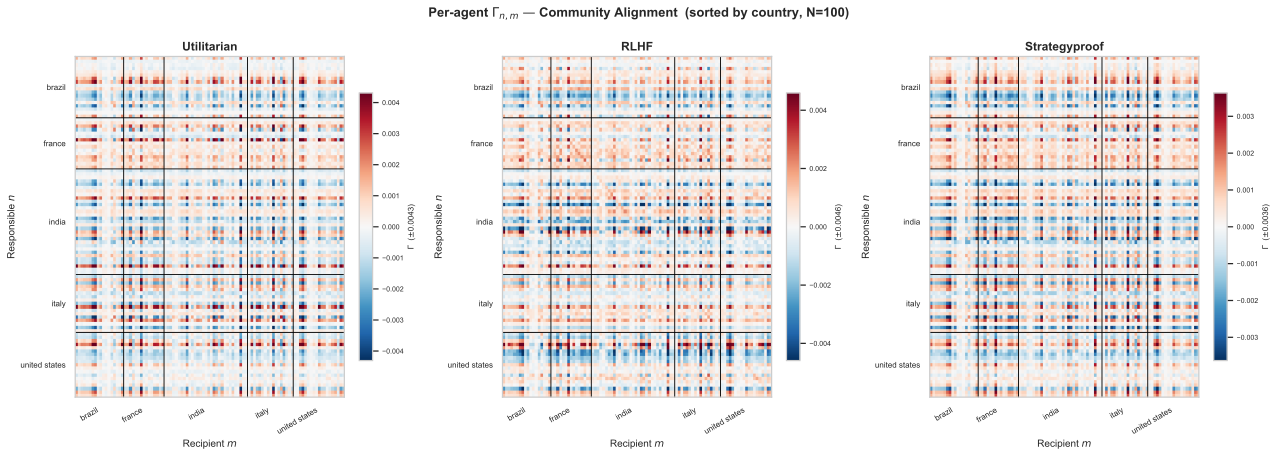

In [63]:
primary_axis = list(group_axes.keys())[0]
g_arr        = group_axes[primary_axis]
unique_g     = sorted(np.unique(g_arr).tolist())
order        = np.concatenate([np.where(g_arr == g)[0] for g in unique_g])
g_sorted     = g_arr[order]

# Group block boundaries
boundaries, midpoints = [], []
cum = 0
for g in unique_g:
    n_g = int((g_sorted == g).sum())
    midpoints.append(cum + n_g/2 - 0.5)
    cum += n_g
    boundaries.append(cum - 0.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
for ax, (lbl, G) in zip(axes, GAMMAS.items()):
    G_sorted = G[np.ix_(order, order)]
    vs = float(np.percentile(np.abs(G_sorted), 99)) or 1e-12
    im = ax.imshow(G_sorted, cmap="RdBu_r", vmin=-vs, vmax=vs,
                   aspect="auto", interpolation="nearest")
    for b in boundaries[:-1]:
        ax.axhline(b, color="black", lw=0.9)
        ax.axvline(b, color="black", lw=0.9)
    ax.set_xticks(midpoints); ax.set_yticks(midpoints)
    ax.set_xticklabels(unique_g, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(unique_g, fontsize=8)
    ax.set_xlabel("Recipient $m$", fontsize=10)
    ax.set_ylabel("Responsible $n$", fontsize=10)
    ax.grid(False)
    cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.05)
    cb.set_label(rf"$\Gamma$  ($\pm${vs:.4f})", fontsize=8)
    cb.ax.tick_params(labelsize=7)
    ax.set_title(f"{lbl}", fontweight="bold", fontsize=12)

fig.suptitle(f"Per-agent $\\Gamma_{{n,m}}$ — {DATASET}  (sorted by {primary_axis}, N={N_AGENTS})",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

## §7 Group-averaged Γ heatmaps — every group axis × three mechanisms

For each group axis, average Γ within each (group_n, group_m) block. Off-diagonal blocks use the full block mean; diagonal blocks exclude self-pairs.

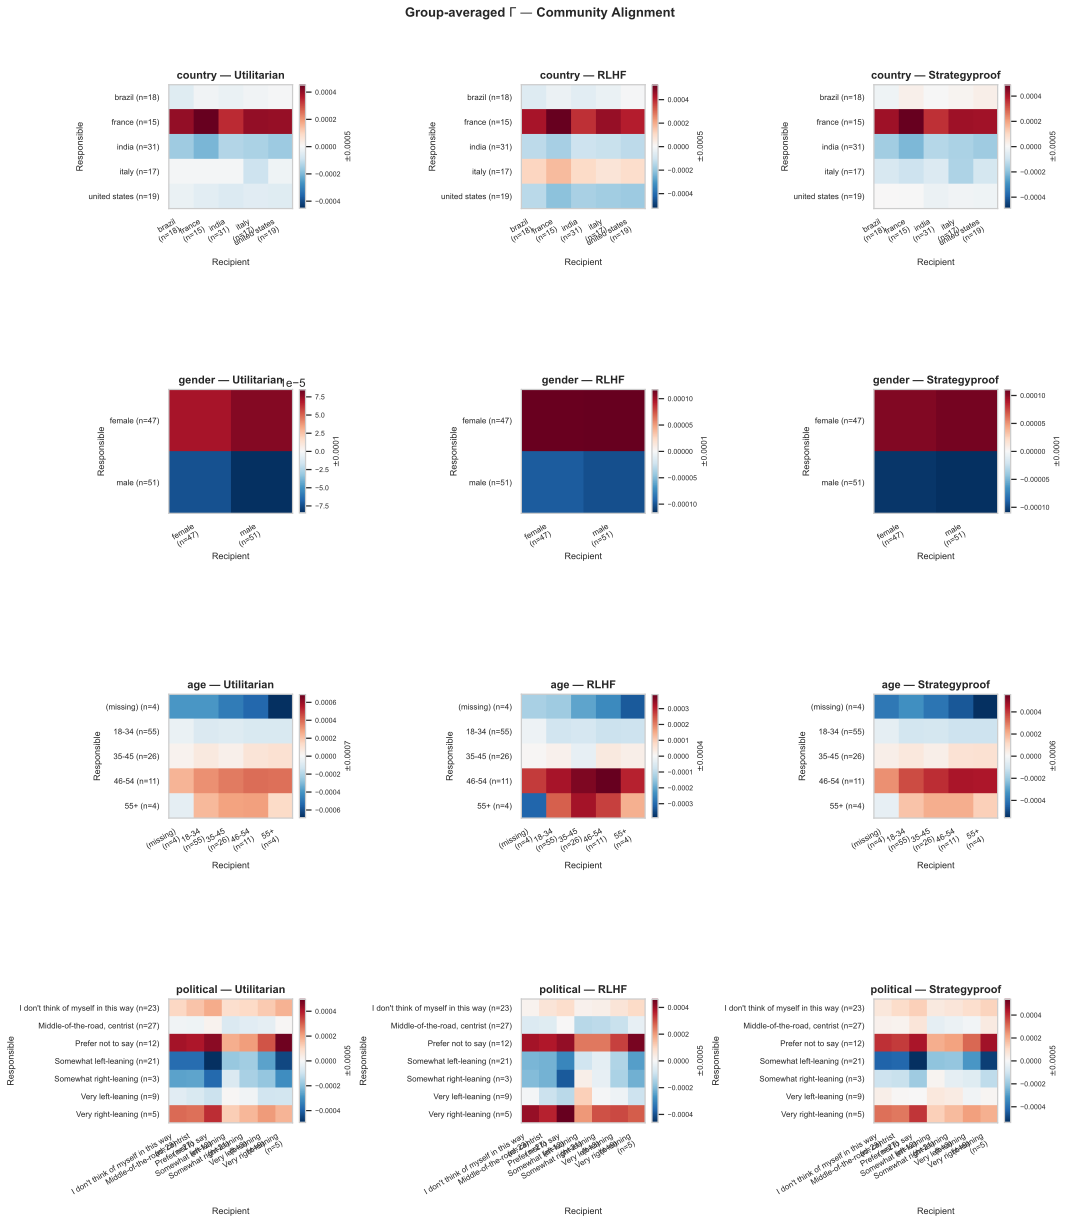

In [64]:
MIN_CELL_N = 3
def gamma_summary_matrix(group_arr, G_full, min_n=MIN_CELL_N):
    g = pd.Series(group_arr).where(lambda s: s.notna(), None).fillna("(missing)").to_numpy()
    counts = pd.Series(g).value_counts()
    keep = set(counts[counts >= min_n].index)
    mask = np.array([gv in keep for gv in g])
    if mask.sum() < 2: return None
    g_sub = g[mask]
    G_sub = G_full[np.ix_(mask, mask)]
    uniq  = sorted(np.unique(g_sub).tolist())
    M     = np.zeros((len(uniq), len(uniq)))
    for i, gn in enumerate(uniq):
        for j, gm in enumerate(uniq):
            block = G_sub[np.ix_(g_sub == gn, g_sub == gm)]
            if i == j:
                od = block[~np.eye(block.shape[0], dtype=bool)]
                M[i, j] = od.mean() if od.size else 0.0
            else:
                M[i, j] = block.mean()
    return M, uniq, {gv: int((g_sub == gv).sum()) for gv in uniq}, int((~mask).sum())

n_axes = len(group_axes)
fig, axes = plt.subplots(n_axes, 3, figsize=(15, 4.5 * n_axes), squeeze=False)
for r, (axis_name, g_arr) in enumerate(group_axes.items()):
    for c, (lbl, G) in enumerate(GAMMAS.items()):
        ax  = axes[r, c]
        res = gamma_summary_matrix(g_arr, G)
        if res is None:
            ax.set_visible(False); continue
        M, uniq, counts, n_drop = res
        vs = float(np.percentile(np.abs(M), 99)) or 1e-12
        im = ax.imshow(M, cmap="RdBu_r", vmin=-vs, vmax=vs)
        ax.set_xticks(range(len(uniq)))
        ax.set_xticklabels([f"{g}\n(n={counts[g]})" for g in uniq],
                           rotation=30, ha="right", fontsize=8)
        ax.set_yticks(range(len(uniq)))
        ax.set_yticklabels([f"{g} (n={counts[g]})" for g in uniq], fontsize=8)
        ax.set_xlabel("Recipient", fontsize=9)
        ax.set_ylabel("Responsible", fontsize=9)
        ax.grid(False)
        cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.05)
        cb.set_label(rf"$\pm${vs:.4f}", fontsize=8)
        cb.ax.tick_params(labelsize=7)
        ax.set_title(f"{axis_name} — {lbl}", fontweight="bold", fontsize=11)
fig.suptitle(f"Group-averaged $\\Gamma$ — {DATASET}", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

## §8 Bounded harm — LP setup

Solve $\max \bar\theta_w^\top \psi$ subject to per-agent floors
$\theta_n^\top \psi \geq b_n$ and $\psi \in \bar\Psi$, for three variants:

- **`BH b=-0.5`**: constant floor $-0.5\,W^*$ (raw units).
- **`BH ε=0.1`**: tight relative floor $-0.1 \, h_{\bar\Psi}(\theta_n)$.
- **`BH ε=0.5`**: medium relative floor $-0.5 \, h_{\bar\Psi}(\theta_n)$.

The LP returns $\psi_{\rm LP}$ (the saturated-$\beta$ optimal impact). We work
directly with $\psi_{\rm LP}$ for $\Gamma$ — no `phi_inv` roundtrip needed since
$\psi_{\rm LP}$ is exactly the impact a deployed $\theta_c$ would realize at the
calibration $\beta$.

In [65]:
from scipy.optimize import linprog

def solve_constrained_lp(theta_obj, normals, thresholds, alpha_dep, return_full=False):
    Z, k = alpha_dep.shape
    c    = -(alpha_dep @ theta_obj)
    A_ub = -(normals @ alpha_dep.T)
    b_ub = -2.0 * Z * thresholds
    bounds = [(-1.0, 1.0)] * Z
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"LP failed: {res.message}")
    psi_opt = 0.5 * (alpha_dep.T @ res.x) / Z
    if return_full:
        eta = np.maximum(0.0, -res.ineqlin.marginals)   # shadow prices on agent floors
        return psi_opt, eta, res
    return psi_opt

# W* under boundary utilitarian (β=∞)
psi_star_inf = 0.5 * (alpha_q * np.sign(alpha_q @ theta_bar)[:, None]).mean(axis=0)
W_star = float(theta_bar @ psi_star_inf)

# h_Ψ̄(θ_n) per agent: max possible welfare for agent n in Ψ̄
def hub_of(T):
    return 0.5 * np.abs(alpha_q @ T.T).mean(axis=0)

hub_full = hub_of(Theta)

# Per-variant threshold function on a Theta_sub (used both for full and LOO)
THRESH_FN = {
    # "BH  b=-0.5": lambda T: -0.5 * W_star * np.ones(T.shape[0]),
    # "BH  ε=0.1":  lambda T: -0.1 * hub_of(T),
    "BH  ε=0.05": lambda T: -0.05 * hub_of(T),
}

BH_PSI = {}
BH_ETA = {}
for lbl, fn in THRESH_FN.items():
    psi_lp, eta, _ = solve_constrained_lp(theta_bar, Theta, fn(Theta), alpha_q, return_full=True)
    BH_PSI[lbl] = psi_lp
    BH_ETA[lbl] = eta

# ψ_util is the unconstrained utilitarian boundary impact at β=∞.
psi_util_inf = psi_star_inf

print(f"W* = {W_star:.4f}")
print(f"{'mech':14s}  {'||ψ_LP||':>10s}  {'θ̄·ψ_LP/W*':>12s}  "
      f"{'||ψ_LP-ψ*||':>12s}  {'#binding':>10s}")
for lbl, psi_lp in BH_PSI.items():
    eta = BH_ETA[lbl]
    n_bind = int((eta > 1e-6).sum())
    gap = float(np.linalg.norm(psi_lp - psi_util_inf))
    print(f"  {lbl:12s}  {np.linalg.norm(psi_lp):>10.4f}  "
          f"{theta_bar @ psi_lp / W_star:>+12.4f}  "
          f"{gap:>12.4e}  {n_bind:>10d}")
if all(int((BH_ETA[lbl] > 1e-6).sum()) == 0 for lbl in BH_PSI):
    print("\n!! WARNING: NO agent floors are binding for any BH variant.")
    print("   ψ_BH = ψ_util  →  LOO ψ_BH^(-n) = ψ_BH for all n  →  Γ_BH = 0.")
    print("   With the stratified sample, the agent set may be too homogeneous")
    print("   for the floors to bind. Try tightening floors (smaller ε), using")
    print("   STRATIFIED_N=None to fit on all agents, or sampling more diverse agents.")

# --- Pre-LP diagnostic: how many agents would be VIOLATED at ψ_util? ---
# This is exactly what determines how many constraints will bind at the LP optimum,
# since the LP only needs to bend ψ to satisfy the violated ones.
W_util_per_agent = Theta @ psi_util_inf                       # (N,)
hub_n            = 0.5 * np.abs(alpha_q @ Theta.T).mean(axis=0)  # (N,)

# Distribution of utilitarian welfare normalized by each agent's max possible
norm_util = W_util_per_agent / np.maximum(hub_n, 1e-12)
print(f"\nDistribution of θ_n·ψ* / h_Ψ̄(θ_n)  across N={N_AGENTS} agents:")
for q in [1, 5, 10, 25, 50, 75, 100]:
    print(f"  p{q:>3d}: {np.percentile(norm_util, q):+.4f}")

print(f"\nAt ψ_util, # agents with W_n < -ε·h_Ψ̄(θ_n)  (would bind in LP):")
for eps in [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]:
    n_viol = int((W_util_per_agent < -eps * hub_n).sum())
    print(f"  ε = {eps:>5.3f}    {n_viol:>4d} / {N_AGENTS}   ({100*n_viol/N_AGENTS:5.1f} %)")

print("\nPick an ε whose violation count matches your desired #binding.")
print("If even ε ≈ 0 gives few violations, the sample is too well-aligned with θ̄;")
print("set STRATIFIED_N = None or sample more diverse agents.")


W* = 0.3483
mech              ||ψ_LP||    θ̄·ψ_LP/W*   ||ψ_LP-ψ*||    #binding
  BH  ε=0.05        0.2048       +0.9198    1.1868e-01           1

Distribution of θ_n·ψ* / h_Ψ̄(θ_n)  across N=100 agents:
  p  1: -0.2777
  p  5: -0.0600
  p 10: +0.1818
  p 25: +0.7510
  p 50: +0.9075
  p 75: +0.9622
  p100: +0.9936

At ψ_util, # agents with W_n < -ε·h_Ψ̄(θ_n)  (would bind in LP):
  ε = 0.001       8 / 100   (  8.0 %)
  ε = 0.005       8 / 100   (  8.0 %)
  ε = 0.010       8 / 100   (  8.0 %)
  ε = 0.020       8 / 100   (  8.0 %)
  ε = 0.050       6 / 100   (  6.0 %)
  ε = 0.100       4 / 100   (  4.0 %)
  ε = 0.200       3 / 100   (  3.0 %)
  ε = 0.300       1 / 100   (  1.0 %)
  ε = 0.500       1 / 100   (  1.0 %)

Pick an ε whose violation count matches your desired #binding.
If even ε ≈ 0 gives few violations, the sample is too well-aligned with θ̄;
set STRATIFIED_N = None or sample more diverse agents.


## §9 BH LOO ψ — re-solve LP excluding each agent

For each variant and each agent $n$, drop row $n$ from the constraint matrix
(`Theta`) and the threshold vector, then re-solve. With the HiGHS solver each LP
takes ~0.1–1 s; total time scales as `3 · N_AGENTS`. For large datasets
(coalign, ~870 agents), expect ~10–30 minutes; reduce by trimming `THRESH_FN`
to fewer variants if needed.

In [66]:
def _bh_tag(lbl):
    return "bh_" + lbl.replace(" ", "").replace("=", "").replace("-", "neg").replace("ε", "eps")

psi_BH_loo = {}
for lbl, threshold_fn in THRESH_FN.items():
    name = _bh_tag(lbl)
    cached = _load_cache(name, agent_ids)
    if cached is not None:
        print(f"  BH LOO loaded from cache: {lbl}  ({_cache_path(name)})")
        psi_BH_loo[lbl] = cached
        continue
    print(f"BH LOO — {lbl}")
    arr = np.zeros((N_AGENTS, K_DIM))
    t0 = time.time()
    for n_idx in range(N_AGENTS):
        keep = np.r_[:n_idx, n_idx + 1:N_AGENTS]
        T_loo = Theta[keep]
        # LOO objective: utilitarian mean of REMAINING agents
        theta_bar_loo = (N_AGENTS * theta_bar - Theta[n_idx]) / (N_AGENTS - 1)
        thr_loo = threshold_fn(T_loo)
        arr[n_idx] = solve_constrained_lp(theta_bar_loo, T_loo, thr_loo, alpha_q)
        if (n_idx + 1) % 100 == 0 or n_idx == 0:
            print(f"    {n_idx+1:4d}/{N_AGENTS}   elapsed {time.time()-t0:5.1f}s")
    print(f"  done in {time.time()-t0:.1f}s")
    psi_BH_loo[lbl] = arr
    _save_cache(name, arr, agent_ids)

  BH LOO loaded from cache: BH  ε=0.05  (loo_cache/Community Alignment_bh_BHeps0.05_N100_beta1.0.npz)


## §10 BH Γ matrices

$$\Gamma^{\rm BH}_{n,m} = \theta_m^\top \bigl(\psi_{\rm LP} - \psi_{\rm LP}^{(-n)}\bigr)$$

Stored alongside the unconstrained Γ in a combined dict for plotting.

In [67]:
# Gamma_BH = {lbl: gamma_mat(BH_PSI[lbl], psi_BH_loo[lbl], Theta) for lbl in THRESH_FN}

# for lbl, G in Gamma_BH.items():
#     print(f"{lbl:14s}  |Γ| range [{np.abs(G).min():.4e}, {np.abs(G).max():.4e}]   "
#           f"diag mean {np.diag(G).mean():+.4e}   off-diag mean "
#           f"{(G - np.diag(np.diag(G))).mean():+.4e}")

## §11 BH per-agent Γ heatmaps (1×3)

In [68]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
# for ax, (lbl, G) in zip(axes, Gamma_BH.items()):
#     G_sorted = G[np.ix_(order, order)]
#     vs = float(np.percentile(np.abs(G_sorted), 99)) or 1e-12
#     im = ax.imshow(G_sorted, cmap="RdBu_r", vmin=-vs, vmax=vs,
#                    aspect="auto", interpolation="nearest")
#     for b in boundaries[:-1]:
#         ax.axhline(b, color="black", lw=0.9)
#         ax.axvline(b, color="black", lw=0.9)
#     ax.set_xticks(midpoints); ax.set_yticks(midpoints)
#     ax.set_xticklabels(unique_g, rotation=30, ha="right", fontsize=8)
#     ax.set_yticklabels(unique_g, fontsize=8)
#     ax.set_xlabel("Recipient $m$", fontsize=10)
#     ax.set_ylabel("Responsible $n$", fontsize=10)
#     ax.grid(False)
#     cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.05)
#     cb.set_label(rf"$\Gamma$  ($\pm${vs:.4f})", fontsize=8)
#     cb.ax.tick_params(labelsize=7)
#     ax.set_title(f"{lbl}", fontweight="bold", fontsize=12)
# fig.suptitle(f"Per-agent $\Gamma_{{n,m}}$ — bounded harm — {DATASET}  "
#              f"(sorted by {primary_axis}, N={N_AGENTS})",
#              fontweight="bold", fontsize=13)
# plt.tight_layout(); plt.show()

## §12 BH group-averaged Γ heatmaps (n_axes × 3)

In [69]:
# n_axes = len(group_axes)
# fig, axes = plt.subplots(n_axes, 3, figsize=(15, 4.5 * n_axes), squeeze=False)
# for r, (axis_name, g_arr) in enumerate(group_axes.items()):
#     for c, (lbl, G) in enumerate(Gamma_BH.items()):
#         ax  = axes[r, c]
#         res = gamma_summary_matrix(g_arr, G)
#         if res is None:
#             ax.set_visible(False); continue
#         M, uniq, counts, n_drop = res
#         vs = float(np.percentile(np.abs(M), 99)) or 1e-12
#         im = ax.imshow(M, cmap="RdBu_r", vmin=-vs, vmax=vs)
#         ax.set_xticks(range(len(uniq)))
#         ax.set_xticklabels([f"{g}\n(n={counts[g]})" for g in uniq],
#                            rotation=30, ha="right", fontsize=8)
#         ax.set_yticks(range(len(uniq)))
#         ax.set_yticklabels([f"{g} (n={counts[g]})" for g in uniq], fontsize=8)
#         ax.set_xlabel("Recipient", fontsize=9)
#         ax.set_ylabel("Responsible", fontsize=9)
#         ax.grid(False)
#         cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.05)
#         cb.set_label(rf"$\pm${vs:.4f}", fontsize=8)
#         cb.ax.tick_params(labelsize=7)
#         ax.set_title(f"{axis_name} — {lbl}", fontweight="bold", fontsize=11)
# fig.suptitle(f"Group-averaged $\Gamma$ — bounded harm — {DATASET}",
#              fontweight="bold", fontsize=13)
# plt.tight_layout(); plt.show()

## §13 Side-by-side: Utilitarian vs Bounded Harm (ε=0.5) — per-agent Γ

Focused two-panel view intended for the Community Alignment writeup. Same agent ordering and country block boundaries as the §6 / §11 grids; each panel uses its own 99th-pct color clip so the dynamic range of each is fully visible.

In [70]:
# Panel 13 (extended): Util vs Bounded Harm Γ for currently-loaded dataset AND 412.
# Top row: currently loaded DATASET (uses globals).  Bottom row: 412 (computed inline).
EPS_BH = 0.05
# Resolve the 412 key in DATASET_LOADERS regardless of whether it was
# registered as "412" or "412 Food Rescue".
KEY_412 = next((k for k in DATASET_LOADERS if "412" in str(k).lower()),
                None)
if KEY_412 is None:
    raise KeyError(f"No key matching '412' in DATASET_LOADERS keys: "
                    f"{list(DATASET_LOADERS)}")

def _compute_panel(ds_key, eps_bh=EPS_BH):
    """Run the full Util + BH-LOO pipeline for any dataset; return everything
       needed to draw the 1×2 row (Gamma_util, Gamma_BH, sort/order, group axis)."""
    alpha_l, y_l, pid_l, _, _, demos_l = DATASET_LOADERS[ds_key]()
    aids_l, T_l = fit_per_user(alpha_l, y_l, pid_l, min_obs=MIN_OBS)
    N_l = T_l.shape[0]
    th_bar = T_l.mean(axis=0)

    rng_l = np.random.default_rng(0)
    if alpha_l.shape[0] > QUERY_SAMPLE:
        idx_l = rng_l.choice(alpha_l.shape[0], size=QUERY_SAMPLE, replace=False)
        aq_l = alpha_l[idx_l]
    else:
        aq_l = alpha_l
    K_l = T_l.shape[1]

    th_util_loo  = (N_l * th_bar - T_l) / (N_l - 1)
    psi_full_u   = psi(th_bar, aq_l, BETA_GAMMA)
    psi_loo_u    = np.array([psi(t, aq_l, BETA_GAMMA) for t in th_util_loo])
    G_util       = (psi_full_u[None, :] - psi_loo_u) @ T_l.T

    hub_full = 0.5 * np.abs(aq_l @ T_l.T).mean(axis=0)
    psi_full_bh = solve_constrained_lp(th_bar, T_l, -eps_bh * hub_full, aq_l)
    psi_loo_bh  = np.zeros((N_l, K_l))
    for n_idx in range(N_l):
        keep   = np.r_[:n_idx, n_idx + 1:N_l]
        T_keep = T_l[keep]
        th_bar_loo = (N_l * th_bar - T_l[n_idx]) / (N_l - 1)
        hub_keep = 0.5 * np.abs(aq_l @ T_keep.T).mean(axis=0)
        psi_loo_bh[n_idx] = solve_constrained_lp(th_bar_loo, T_keep,
                                                  -eps_bh * hub_keep, aq_l)
    G_bh = (psi_full_bh[None, :] - psi_loo_bh) @ T_l.T

    if demos_l:
        primary = list(demos_l.keys())[0]
        ser = demos_l[primary].where(demos_l[primary].notna(), "(missing)").astype(str)
        g_arr_l = np.array([ser.get(a, "(missing)") for a in aids_l])
    else:
        primary = "kmeans"
        Xs = StandardScaler().fit_transform(T_l)
        K_C = min(6, N_l)
        lab = KMeans(n_clusters=K_C, n_init=20, random_state=0).fit_predict(Xs)
        g_arr_l = np.array([f"k{x}" for x in lab])

    uniq = sorted(np.unique(g_arr_l).tolist())
    order_l = np.concatenate([np.where(g_arr_l == g)[0] for g in uniq])
    g_sorted_l = g_arr_l[order_l]
    bnd, mid = [], []
    cum = 0
    for g in uniq:
        n_g = int((g_sorted_l == g).sum())
        mid.append(cum + n_g/2 - 0.5)
        cum += n_g
        bnd.append(cum - 0.5)
    return dict(Gamma_util=G_util, Gamma_BH=G_bh, order=order_l,
                boundaries=bnd, midpoints=mid, unique_g=uniq,
                primary_axis=primary, N=N_l)

results = {}
# Pretty-print mapping; falls back to the raw key if not found.
ds_titles = {"412": "412 Food Rescue", "412 Food Rescue": "412 Food Rescue",
             "kidney": "Kidney Allocation", "Kidney Allocation": "Kidney Allocation",
             "moralmachine": "Moral Machine", "Moral Machine": "Moral Machine",
             "coalign": "Community Alignment", "Community Alignment": "Community Alignment"}

BH_LBL = list(Gamma_BH.keys())[0]
results[DATASET] = dict(Gamma_util=Gamma_util, Gamma_BH=Gamma_BH[BH_LBL],
                        order=order, boundaries=boundaries, midpoints=midpoints,
                        unique_g=unique_g, primary_axis=primary_axis, N=N_AGENTS)

if KEY_412 not in results:
    print(f"computing {KEY_412} panel data ...")
    results[KEY_412] = _compute_panel(KEY_412, eps_bh=EPS_BH)

ds_order = [DATASET, KEY_412] if DATASET != KEY_412 else [KEY_412]
fig, axes = plt.subplots(len(ds_order), 2, figsize=(15, 7 * len(ds_order)),
                          squeeze=False)
for r, ds in enumerate(ds_order):
    rec       = results[ds]
    n_agents  = rec["N"]
    title_pre = ds_titles.get(ds, ds)
    panels_r  = [("Utilitarian", rec["Gamma_util"]),
                 (f"Bounded harm  ε={EPS_BH}", rec["Gamma_BH"])]
    for c, (title, G) in enumerate(panels_r):
        ax = axes[r, c]
        G_sorted = G[np.ix_(rec["order"], rec["order"])]
        vs = float(np.percentile(np.abs(G_sorted), 99)) or 1e-12
        im = ax.imshow(G_sorted, cmap="RdBu_r", vmin=-vs, vmax=vs,
                       aspect="auto", interpolation="nearest")
        for b in rec["boundaries"][:-1]:
            ax.axhline(b, color="black", lw=0.9)
            ax.axvline(b, color="black", lw=0.9)
        ax.set_xticks(rec["midpoints"]); ax.set_yticks(rec["midpoints"])
        ax.set_xticklabels(rec["unique_g"], rotation=30, ha="right", fontsize=10)
        ax.set_yticklabels(rec["unique_g"], fontsize=9)
        ax.set_xlabel("Externality recipient $m$", fontsize=11)
        ax.set_ylabel("Responsible party $n$",   fontsize=11)
        ax.grid(False)
        cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
        cb.set_label(rf"$\Gamma_{{n,m}}$  ($\pm${vs:.4f}, 99th-pct clip)",
                     fontsize=9)
        cb.ax.tick_params(labelsize=8)
        ax.set_title(f"{title_pre} — {title}  (N={n_agents})",
                     fontweight="bold", fontsize=12)

fig.suptitle(r"Per-agent alignment externality $\Gamma$ — Utilitarian vs Bounded Harm",
             fontweight="bold", fontsize=14, y=1.0)
plt.tight_layout(); plt.show()


computing 412 Food Rescue panel data ...


NameError: name 'fit_per_user' is not defined